<a href="https://colab.research.google.com/github/byhaqii/PVCK-2025/blob/main/Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Filter

### b. Access the files contained on the drive and import some of the libraries that are needed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

## 3. Create Image Filter for Average filter, low pass filter, high pass filter, and some of the following filters :

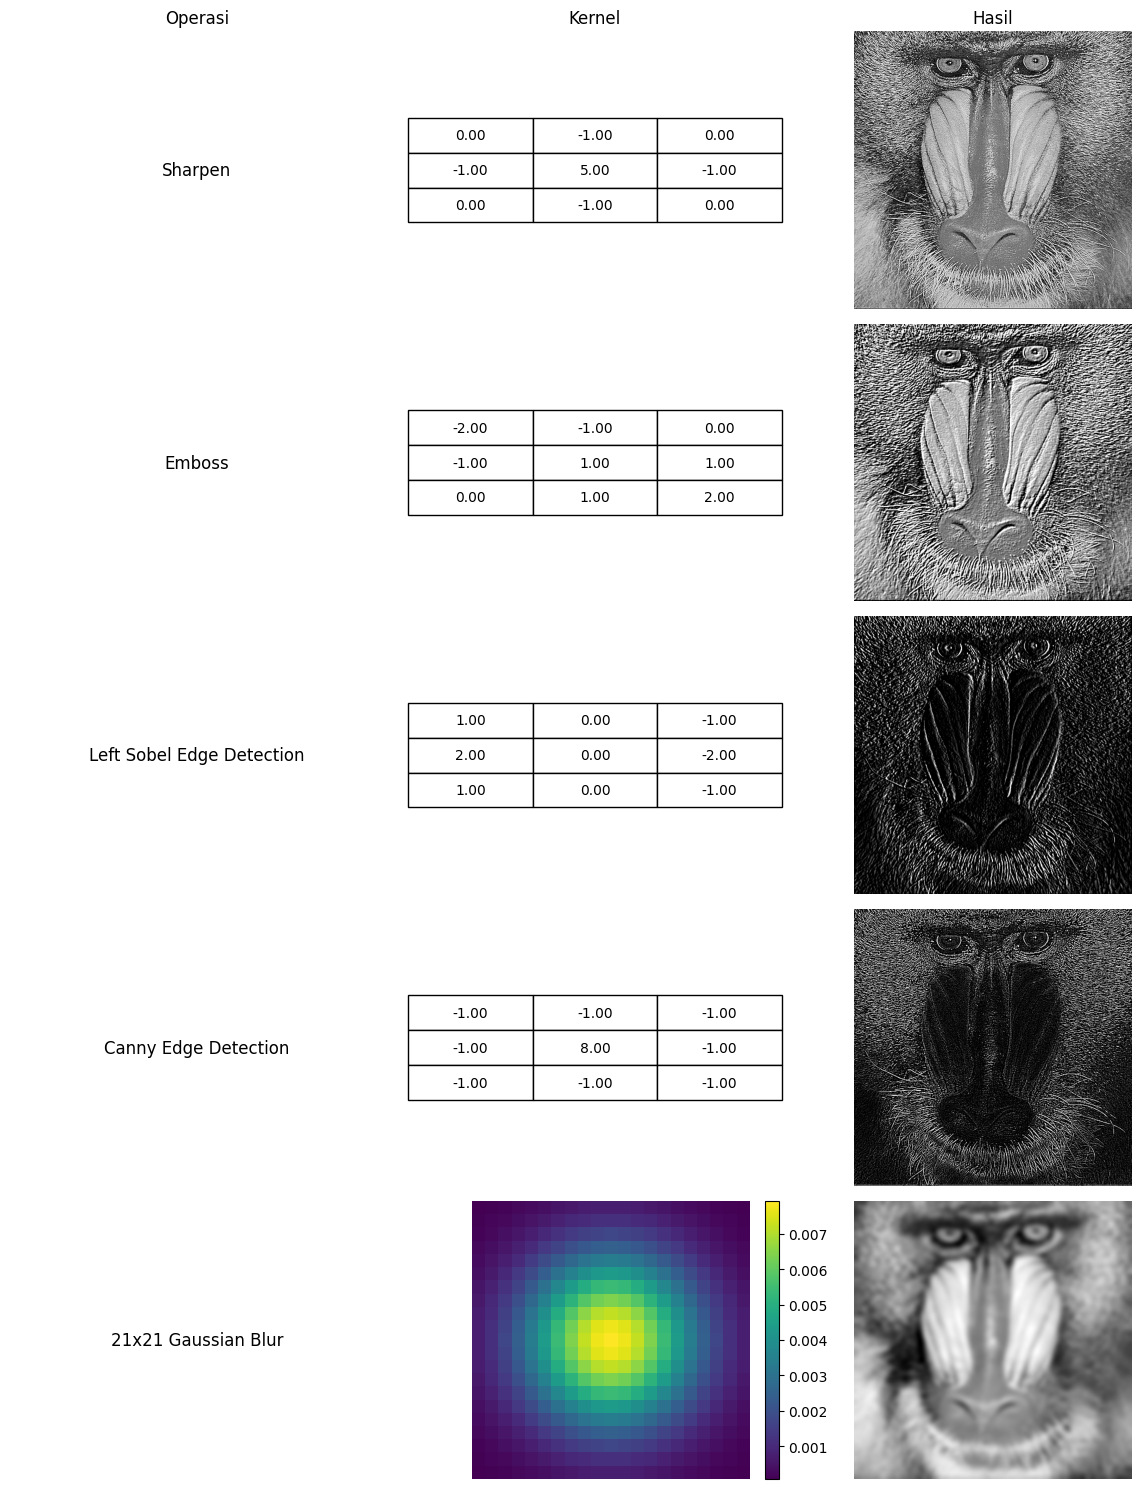

In [ ]:
# -------------------------
# Helper: convolution wrapper
# -------------------------
def convolution2d(img, kernel):
    # ensure kernel is float32
    k = np.array(kernel, dtype=np.float32)
    return cv.filter2D(img, -1, k)

# -------------------------
# Helper: pretty kernel plot
# -------------------------
def plot_kernel(ax, kernel):
    k = np.array(kernel, dtype=np.float32)
    ax.axis("off")
    max_dim = max(k.shape)
    if k.size <= 25:  # small kernel -> show as table of values
        # format numbers
        cell_text = [[f"{val:.2f}" for val in row] for row in k]
        table = ax.table(cellText=cell_text, loc="center", cellLoc="center")
        table.scale(1, 1.5)
    else:  # large kernel -> show heatmap
        im = ax.imshow(k, cmap="viridis", interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        # add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# -------------------------
# Load image (grayscale)
# -------------------------
img_path = '/content/drive/MyDrive/Images/mandrill.tiff'
img = cv.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Cannot find image at: {img_path}")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# -------------------------
# Define kernels
# -------------------------
kernelS = np.array([[0, -1,  0],
                    [-1, 5, -1],
                    [0, -1,  0]], dtype=np.float32)

kernelE = np.array([[-2, -1, 0],
                    [-1,  1, 1],
                    [0,   1, 2]], dtype=np.float32)

kernelLSED = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]], dtype=np.float32)

kernelCED = np.array([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1]], dtype=np.float32)

kernel_size = 21
sigma = math.sqrt(kernel_size)
g_col = cv.getGaussianKernel(kernel_size, sigma).astype(np.float32)   # column vector
gauss_kernel = (g_col @ g_col.T).astype(np.float32)                  # 2D 21x21 kernel

# -------------------------
# Apply filters
# -------------------------
sharpened     = convolution2d(img_gray, kernelS)
embossed      = convolution2d(img_gray, kernelE)
sobel_left    = convolution2d(img_gray, kernelLSED)
canny_like    = convolution2d(img_gray, kernelCED)
gaussian_blur = convolution2d(img_gray, gauss_kernel)

# -------------------------
# Prepare table data
# -------------------------
titles = ["Sharpen", "Emboss", "Left Sobel Edge Detection",
          "Canny Edge Detection", "21x21 Gaussian Blur"]

kernels = [kernelS, kernelE, kernelLSED, kernelCED, gauss_kernel]
results = [sharpened, embossed, sobel_left, canny_like, gaussian_blur]

# -------------------------
# Plot Operasi | Kernel | Hasil
# -------------------------
n = len(results)
fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3*n))

for i in range(n):
    # Column 0: Operation name
    ax0 = axes[i, 0]
    ax0.axis("off")
    ax0.text(0.5, 0.5, titles[i], fontsize=12, ha="center", va="center")
    if i == 0:
        ax0.set_title("Operasi")

    # Column 1: Kernel (table or heatmap)
    ax1 = axes[i, 1]
    plot_kernel(ax1, kernels[i])
    if i == 0:
        ax1.set_title("Kernel")

    # Column 2: Result image
    ax2 = axes[i, 2]
    ax2.imshow(results[i], cmap="gray")
    ax2.axis("off")
    if i == 0:
        ax2.set_title("Hasil")

plt.tight_layout()
plt.show()

E. FILTER LIBRARY AND MODERN FILTER

Experiment 1:

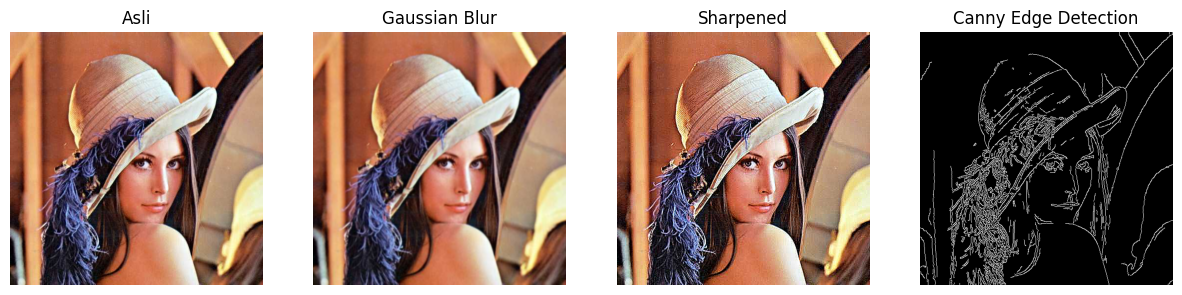

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/Images/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img,(7,7),1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

This program applies several filters to an image using OpenCV and displays the results side by side. The original image is first loaded and converted to grayscale. Then, a Gaussian Blur filter is applied to make the image look smoother by reducing noise and detail. Next, a sharpening filter is used to make edges and textures appear clearer and more defined. Finally, the Canny Edge Detection filter detects and outlines the edges in the image, showing the object’s structure in black and white. All results are displayed together so we can easily compare the effect of each filter.

Experiment 2:

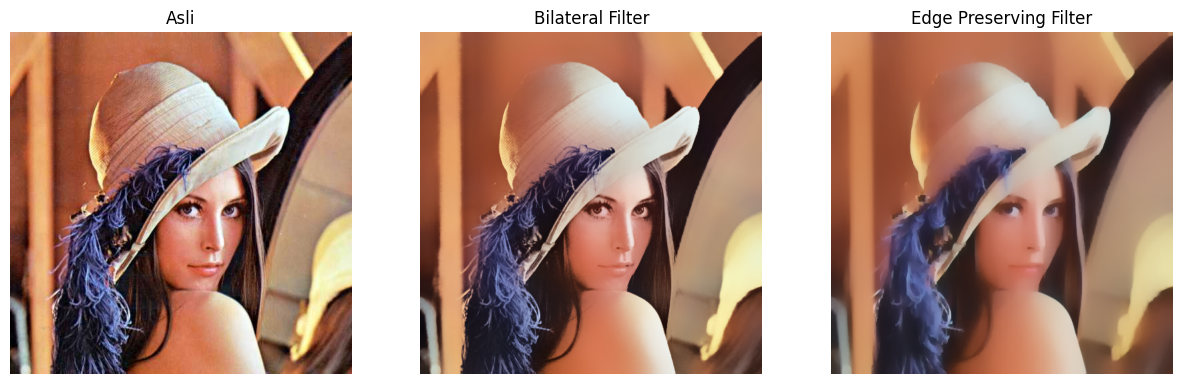

In [ ]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

This experiment compares two modern filters from OpenCV that smooth an image while keeping its edges clear. The Bilateral Filter reduces noise and softens flat areas but still preserves the edges, making it ideal for beauty or skin-smoothing effects. The Edge Preserving Filter (similar to a guided filter) provides a similar result but works faster and produces smoother transitions between colors. Both filters make the image look softer and cleaner without losing important details along the edges.

Difference between Bilateral and Guided Filter:

- Experiment 1 uses basic filters (Gaussian Blur, Sharpen, and Canny Edge Detection).

These filters directly modify pixel intensity — Gaussian Blur smooths everything, Sharpen increases contrast, and Canny only shows the edges. They don’t try to keep both smooth areas and edges at the same time.

- Experiment 2 uses modern filters (Bilateral and Edge Preserving Filter).

These filters are smarter — they smooth the image while protecting edges. Instead of blurring everything equally, they keep edges clear and only soften similar-colored areas. That’s why they’re used for “beauty” or “photo enhancement” effects.

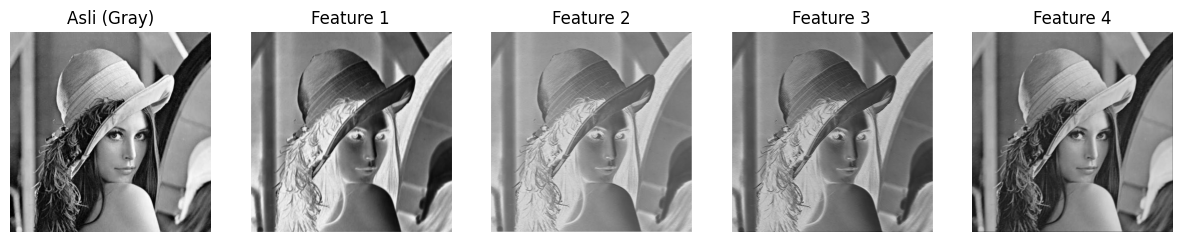

In [ ]:
# Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps,
                  ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

This experiment demonstrates how a Convolutional Neural Network (CNN) processes images using filters to extract features automatically. The code defines a simple CNN layer with four filters, then converts the grayscale image into a tensor and passes it through the network. The output, called feature maps, shows how each filter detects different patterns such as edges, textures, or brightness changes. Each “Feature” image represents the part of the original picture that a specific filter focuses on. This process is the basic idea behind how CNNs learn to recognize objects and important details in images.

This code defines and applies a simple convolutional neural network (CNN) to visualize feature maps. A class SimpleCNN is created with a single convolutional layer that takes one input channel (grayscale image) and produces four output channels using 3×3 kernels with stride 1 and padding 1, ensuring the output size matches the input. The grayscale image is converted into a PyTorch tensor, normalized to values between 0 and 1, and reshaped into the format [batch, channel, height, width]. The image tensor is then passed through the CNN, generating four feature maps, each corresponding to one convolution filter. These feature maps are extracted and converted into NumPy arrays for visualization. Finally, the original grayscale image and the resulting feature maps are displayed side by side, illustrating how convolution filters transform the input image into different feature representations.

In [ ]:
# =================
# 1. Beauty Filter
# =================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# =================
# 2. Old/Vintage Filter
# =================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

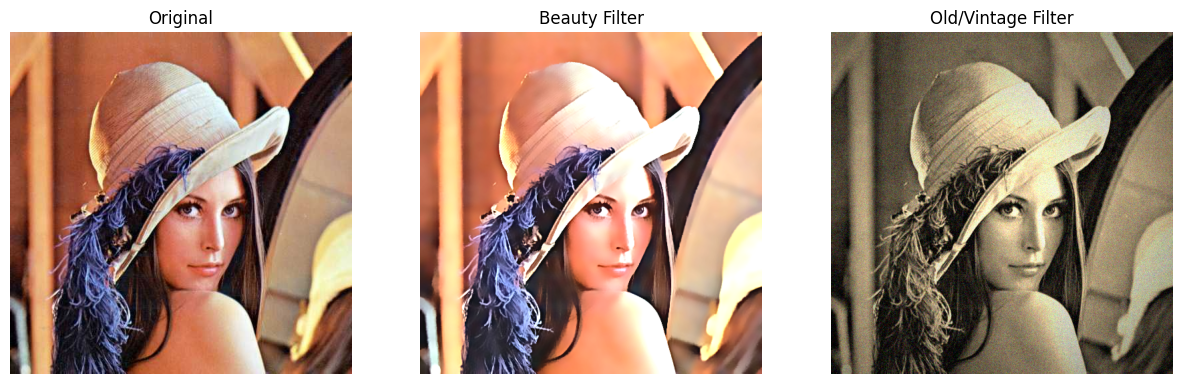

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv.cvtColor(beauty, cv.COLOR_BGR2RGB))
plt.title("Beauty Filter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(old_img, cv.COLOR_BGR2RGB))
plt.title("Old/Vintage Filter")
plt.axis("off")

plt.show()

This code applies two different image filters: a beauty filter and an old/vintage filter. In the beauty filter, the image is first smoothed using a bilateral filter to reduce skin imperfections while preserving edges. Next, unsharp masking is applied by blending the smoothed image with a blurred version to enhance important details such as eyes or lips. Finally, brightness and contrast adjustments are made using scaling factors to make the image appear clearer and more vibrant. For the old/vintage filter, the process begins by applying a sepia tone transformation using a color conversion matrix, giving the image a warm, classic look. A vignette effect is then created by generating Gaussian masks for both rows and columns, darkening the edges of the image while keeping the center brighter. Lastly, random noise is added to simulate film grain, producing a nostalgic, aged appearance. Together, these steps demonstrate how multiple image processing techniques can be combined to achieve modern beautification effects or retro vintage styles

Experiment 5:

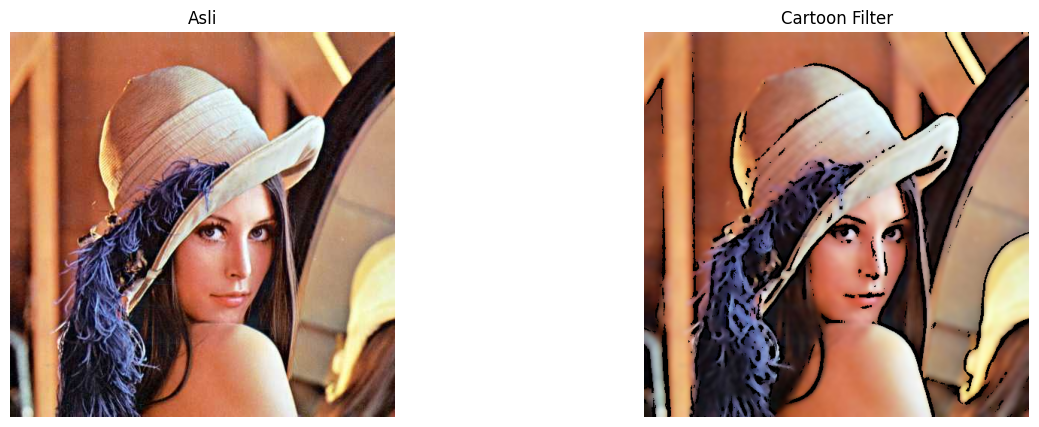

In [ ]:
# Filter Anime / Cartoon

# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

This code creates a cartoon or anime-style filter by combining edge detection with color smoothing. First, the image is converted to grayscale and smoothed using a median blur to reduce noise and make the edges cleaner. Then, adaptive thresholding is applied to detect strong edges, producing a binary edge mask. Next, the original image is smoothed with a bilateral filter, which reduces color variation while preserving important edges, resulting in a painting-like effect. Finally, the smoothed color image is combined with the detected edges using a bitwise operation, so that the outlines are emphasized while the colors remain soft and uniform. The result is a cartoonized version of the image that has bold edges and smooth, flat colors.

**Experiment 6:**

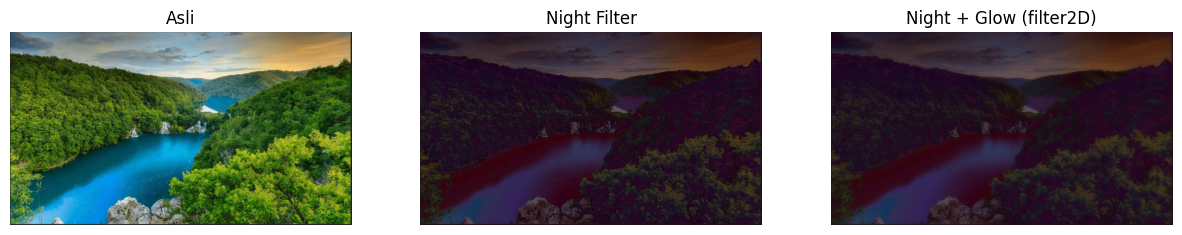

In [ ]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/Images/jungle.png")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

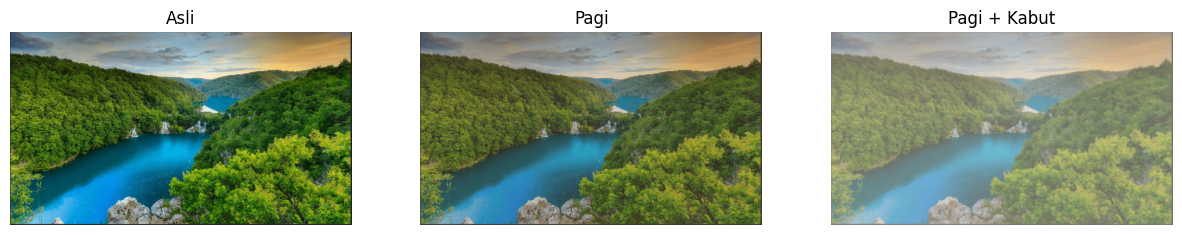

In [ ]:
# Filter Suasana pagi dan Kabut
# =============================
# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])